### Conhecendo os dados

In [1]:
import pandas as pd

In [2]:
df = pd.read_csv('/content/drive/MyDrive/Dados_Csv/imigrantes_canada.csv')
df

,País,Continente,Região,1980,1981,1982,1983,1984,1985,1986,...,2005,2006,2007,2008,2009,2010,2011,2012,2013,Total
0,Afeganistão,Ásia,Sul da Ásia,16,39,39,47,71,340,496,...,3436,3009,2652,2111,1746,1758,2203,2635,2004,58639
1,Albânia,Europa,Sul da Europa,1,0,0,0,0,0,1,...,1223,856,702,560,716,561,539,620,603,15699
2,Argélia,África,Norte da África,80,67,71,69,63,44,69,...,3626,4807,3623,4005,5393,4752,4325,3774,4331,69439
3,Samoa Americana,Oceânia,Polinésia,0,1,0,0,0,0,0,...,0,1,0,0,0,0,0,0,0,6
4,Andorra,Europa,Sul da Europa,0,0,0,0,0,0,2,...,0,1,1,0,0,0,0,1,1,15
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
190,Vietnã,Ásia,Sudeste Asiático,1191,1829,2162,3404,7583,5907,2741,...,1852,3153,2574,1784,2171,1942,1723,1731,2112,97146
191,Saara Ocidental,África,Norte da África,0,0,0,0,0,0,0,...,0,1,0,0,0,0,0,0,0,2
192,Iémen,Ásia,Ásia Ocidental,1,2,1,6,0,18,7,...,161,140,122,133,128,211,160,174,217,2985
193,Zâmbia,África,África Oriental,11,17,11,7,16,9,15,...,91,77,71,64,60,102,69,46,59,1677


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 195 entries, 0 to 194
Data columns (total 38 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   País        195 non-null    object
 1   Continente  195 non-null    object
 2   Região      195 non-null    object
 3   1980        195 non-null    int64 
 4   1981        195 non-null    int64 
 5   1982        195 non-null    int64 
 6   1983        195 non-null    int64 
 7   1984        195 non-null    int64 
 8   1985        195 non-null    int64 
 9   1986        195 non-null    int64 
 10  1987        195 non-null    int64 
 11  1988        195 non-null    int64 
 12  1989        195 non-null    int64 
 13  1990        195 non-null    int64 
 14  1991        195 non-null    int64 
 15  1992        195 non-null    int64 
 16  1993        195 non-null    int64 
 17  1994        195 non-null    int64 
 18  1995        195 non-null    int64 
 19  1996        195 non-null    int64 
 20  1997      

In [4]:
df.set_index('País', inplace=True)

In [5]:
anos = list(map(str, range(1980, 2014)))
anos

['1980',
 '1981',
 '1982',
 '1983',
 '1984',
 '1985',
 '1986',
 '1987',
 '1988',
 '1989',
 '1990',
 '1991',
 '1992',
 '1993',
 '1994',
 '1995',
 '1996',
 '1997',
 '1998',
 '1999',
 '2000',
 '2001',
 '2002',
 '2003',
 '2004',
 '2005',
 '2006',
 '2007',
 '2008',
 '2009',
 '2010',
 '2011',
 '2012',
 '2013']

In [6]:
brasil = df.loc['Brasil', anos]
brasil_tab = pd.DataFrame(brasil)
brasil_tab.reset_index(inplace=True)
brasil_tab = brasil_tab.rename(columns={'index':'anos'})
brasil_tab

,anos,Brasil
0,1980,211
1,1981,220
2,1982,192
3,1983,139
4,1984,145
5,1985,130
6,1986,205
7,1987,244
8,1988,394
9,1989,650


In [7]:
brasil_dict = {'ano': brasil.index.tolist(),
               'imigrantes': brasil.values.tolist()}
dados_brasil = pd.DataFrame(brasil_dict)
dados_brasil

,ano,imigrantes
0,1980,211
1,1981,220
2,1982,192
3,1983,139
4,1984,145
5,1985,130
6,1986,205
7,1987,244
8,1988,394
9,1989,650


In [8]:
import matplotlib.pyplot as plt

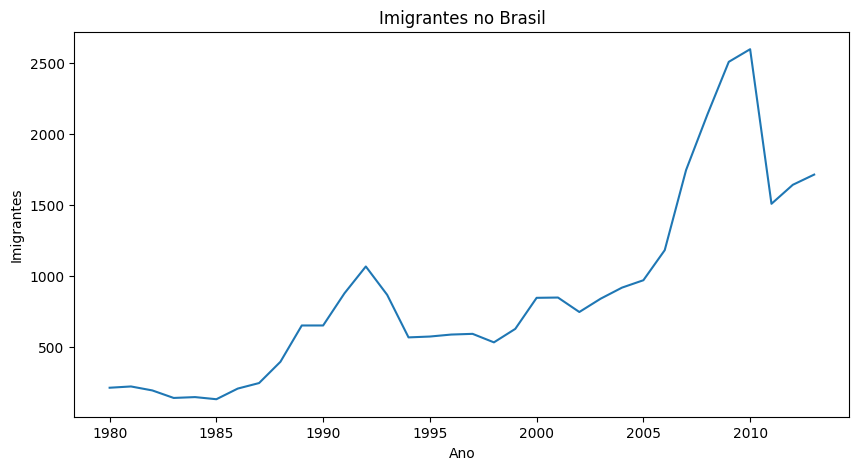

In [9]:
plt.figure(figsize=(10,5))
plt.plot(dados_brasil['ano'], dados_brasil['imigrantes'])
plt.title('Imigrantes no Brasil')
plt.xlabel('Ano')
plt.ylabel('Imigrantes')
plt.xticks(['1980', '1985', '1990', '1995', '2000', '2005', '2010'])
plt.show()

In [10]:
dados_argentina = df.loc['Argentina', anos].reset_index().rename(columns={'index': 'Anos'})
dados_argentina

,Anos,Argentina
0,1980,368
1,1981,426
2,1982,626
3,1983,241
4,1984,237
5,1985,196
6,1986,213
7,1987,519
8,1988,374
9,1989,538


In [11]:
brasil_tab.rename(columns={'anos': 'Anos'}, inplace=True)

In [12]:
dados = pd.merge(dados_argentina, brasil_tab, on='Anos')

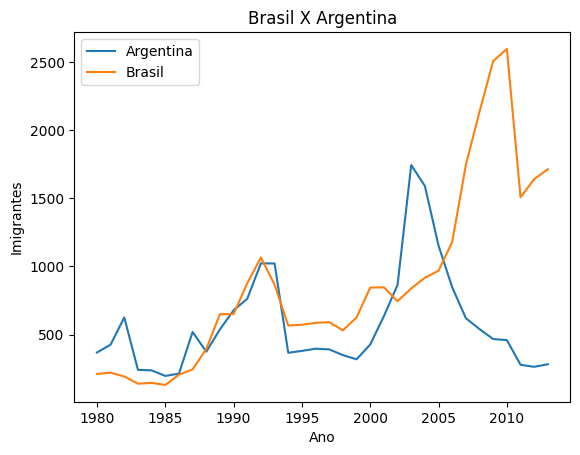

In [13]:
plt.plot(dados['Anos'], dados['Argentina'], label='Argentina')
plt.plot(dados['Anos'], dados['Brasil'], label='Brasil')
plt.title('Brasil X Argentina')
plt.xlabel('Ano')
plt.ylabel('Imigrantes')
plt.xticks(['1980', '1985', '1990', '1995', '2000', '2005', '2010'])
plt.legend()
plt.show()

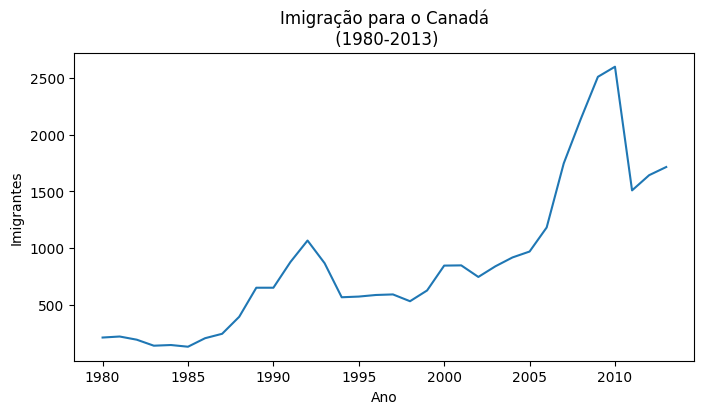

In [14]:
fig, ax = plt.subplots(figsize=(8,4))
ax.plot(dados_brasil['ano'], dados_brasil['imigrantes'])
ax.set_title('Imigração para o Canadá\n (1980-2013)')
ax.set_xlabel('Ano')
ax.set_ylabel('Imigrantes')
ax.xaxis.set_major_locator(plt.MultipleLocator(5))
plt.show()


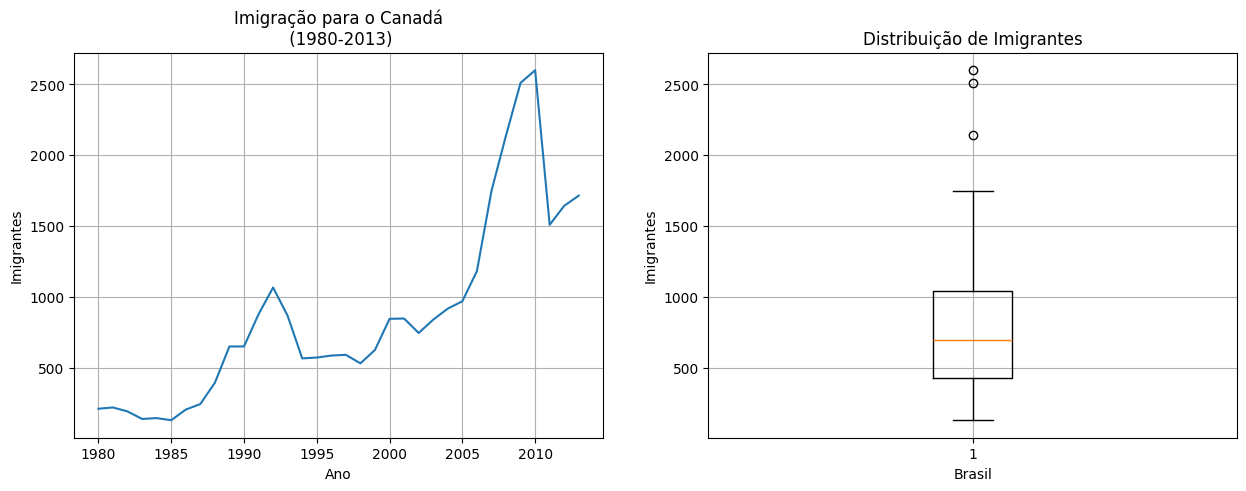

In [15]:
fig, axs = plt.subplots(1, 2, figsize=(15,5))

axs[0].plot(dados_brasil['ano'], dados_brasil['imigrantes'])
axs[0].set_title('Imigração para o Canadá\n (1980-2013)')
axs[0].set_xlabel('Ano')
axs[0].set_ylabel('Imigrantes')
axs[0].xaxis.set_major_locator(plt.MultipleLocator(5))
axs[0].grid(True)

axs[1].boxplot(dados_brasil['imigrantes'])
axs[1].set_title('Distribuição de Imigrantes')
axs[1].set_xlabel('Brasil')
axs[1].set_ylabel('Imigrantes')
axs[1].grid(True)

plt.show()

In [16]:
dados_brasil.describe()

,imigrantes
count,34.000000
mean,872.323529
std,663.401232
min,130.000000
25%,428.250000
50%,697.500000
75%,1041.750000
max,2598.000000


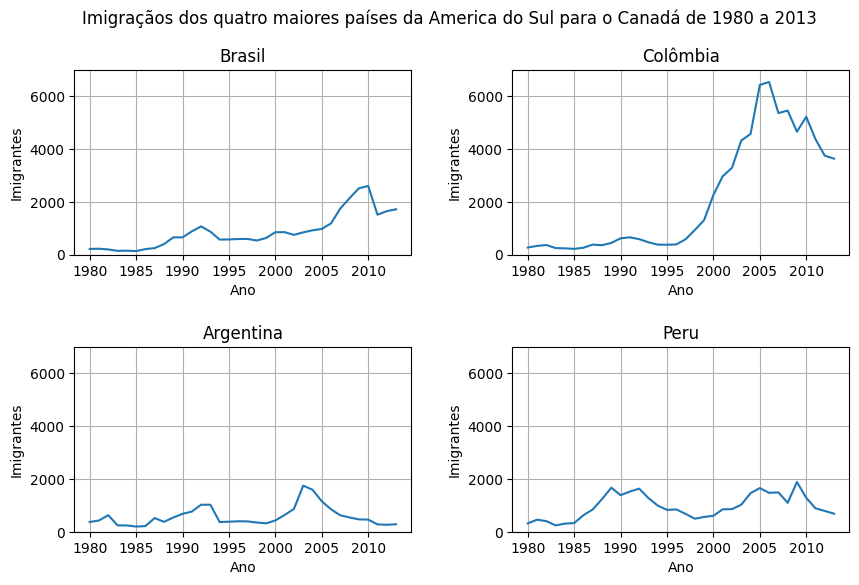

In [17]:
fig, axs = plt.subplots(2,2, figsize=(10,6))
fig.subplots_adjust(hspace=0.5, wspace=0.3)
fig.suptitle('Imigraçãos dos quatro maiores países da America do Sul para o Canadá de 1980 a 2013')

axs[0,0].plot(df.loc['Brasil', anos])
axs[0,0].set_title('Brasil')

axs[0,1].plot(df.loc['Colômbia', anos])
axs[0,1].set_title('Colômbia')

axs[1,0].plot(df.loc['Argentina', anos])
axs[1,0].set_title('Argentina')

axs[1,1].plot(df.loc['Peru', anos])
axs[1,1].set_title('Peru')

for x in range(2):
  for y in range(2):
    axs[x,y].set_xlabel('Ano')
    axs[x,y].set_ylabel('Imigrantes')
    axs[x,y].grid(True)
    axs[x,y].xaxis.set_major_locator(plt.MultipleLocator(5))

# Também poderia ser feito usando:
# for ax in axs.flat:
# ax.xaxis.set_major_locator(plt.MultipleLocator(5))
# ax.set_xlabel('Ano')
# ax.set_ylabel('Imigrantes')
# ax.grid(True)

ymin = 0
ymax = 7000

for ax in axs.ravel():
  ax.set_ylim(ymin,ymax)


plt.show()

In [18]:
lojas = ['A', 'B', 'C', 'D']

vendas_2022 = {'Jan': [100, 80, 150, 50],
    'Fev': [120, 90, 170, 60],
    'Mar': [150, 100, 200, 80],
    'Abr': [180, 110, 230, 90],
    'Mai': [220, 190, 350, 200],
    'Jun': [230, 150, 280, 120],
    'Jul': [250, 170, 300, 140],
    'Ago': [260, 180, 310, 150],
    'Set': [240, 160, 290, 130],
    'Out': [220, 140, 270, 110],
    'Nov': [400, 220, 350, 190],
    'Dez': [300, 350, 400, 250]
}

In [19]:
vendas_2022_df = pd.DataFrame(vendas_2022, index=lojas)
vendas_2022_df = vendas_2022_df.T
vendas_2022_df.reset_index(inplace=True)
vendas_2022_df.rename(columns={'index': 'Meses'}, inplace=True)
vendas_2022_df

,Meses,A,B,C,D
0,Jan,100,80,150,50
1,Fev,120,90,170,60
2,Mar,150,100,200,80
3,Abr,180,110,230,90
4,Mai,220,190,350,200
5,Jun,230,150,280,120
6,Jul,250,170,300,140
7,Ago,260,180,310,150
8,Set,240,160,290,130
9,Out,220,140,270,110


In [20]:
Meses = list(vendas_2022_df['Meses'].unique())

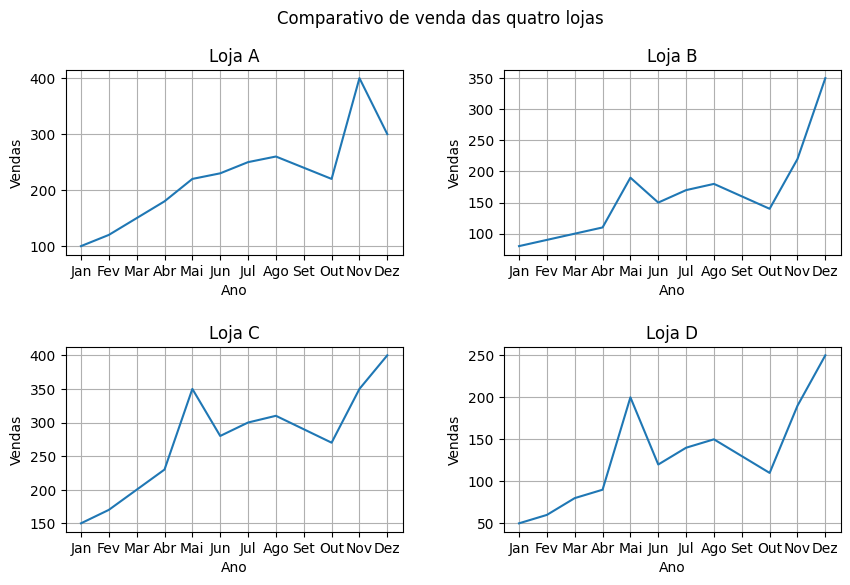

In [21]:
fig, axs = plt.subplots(2,2, figsize=(10,6))
fig.subplots_adjust(hspace=0.5, wspace=0.3)
fig.suptitle('Comparativo de venda das quatro lojas')

axs[0,0].plot(vendas_2022_df['Meses'], vendas_2022_df['A'])
axs[0,0].set_title('Loja A')

axs[0,1].plot(vendas_2022_df['Meses'], vendas_2022_df['B'])
axs[0,1].set_title('Loja B')

axs[1,0].plot(vendas_2022_df['Meses'], vendas_2022_df['C'])
axs[1,0].set_title('Loja C')

axs[1,1].plot(vendas_2022_df['Meses'], vendas_2022_df['D'])
axs[1,1].set_title('Loja D')

for x in range(2):
  for y in range(2):
    axs[x,y].set_xlabel('Ano')
    axs[x,y].set_ylabel('Vendas')
    axs[x,y].grid(True)



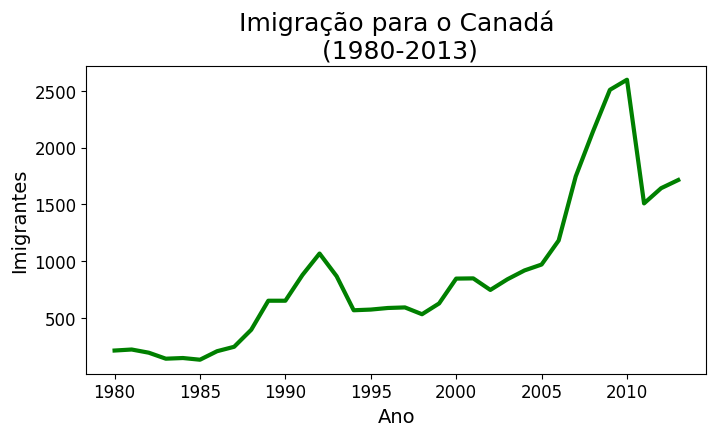

In [22]:
fig, ax = plt.subplots(figsize=(8,4))
ax.plot(dados_brasil['ano'], dados_brasil['imigrantes'], lw=3, color='green')
ax.set_title('Imigração para o Canadá\n (1980-2013)', fontsize=18)
ax.set_xlabel('Ano', fontsize=14)
ax.set_ylabel('Imigrantes', fontsize=14)
ax.xaxis.set_tick_params(labelsize=12)
ax.yaxis.set_tick_params(labelsize=12)
ax.xaxis.set_major_locator(plt.MultipleLocator(5))
plt.show()


In [23]:
df.head()

,Continente,Região,1980,1981,1982,1983,1984,1985,1986,1987,...,2005,2006,2007,2008,2009,2010,2011,2012,2013,Total
País,,,,,,,,,,,,,,,,,,,,,
Afeganistão,Ásia,Sul da Ásia,16,39,39,47,71,340,496,741,...,3436,3009,2652,2111,1746,1758,2203,2635,2004,58639
Albânia,Europa,Sul da Europa,1,0,0,0,0,0,1,2,...,1223,856,702,560,716,561,539,620,603,15699
Argélia,África,Norte da África,80,67,71,69,63,44,69,132,...,3626,4807,3623,4005,5393,4752,4325,3774,4331,69439
Samoa Americana,Oceânia,Polinésia,0,1,0,0,0,0,0,1,...,0,1,0,0,0,0,0,0,0,6
Andorra,Europa,Sul da Europa,0,0,0,0,0,0,2,0,...,0,1,1,0,0,0,0,1,1,15


In [24]:
df['Região'].unique()

array(['Sul da Ásia', 'Sul da Europa', 'Norte da África', 'Polinésia',
       'África média', 'Caribe', 'América do Sul', 'Ásia Ocidental',
       'Austrália e Nova Zelândia', 'Europa Ocidental', 'Europa Oriental',
       'América Central', 'África Ocidental', 'África do Sul',
       'Sudeste Asiático', 'África Oriental', 'América do Norte',
       'Ásia Oriental', 'Norte da Europa', 'Melanesia', 'Ásia Central',
       'Micronésia'], dtype=object)

In [25]:
america_sul = df.query('Região == "América do Sul"')
america_sul

,Continente,Região,1980,1981,1982,1983,1984,1985,1986,1987,...,2005,2006,2007,2008,2009,2010,2011,2012,2013,Total
País,,,,,,,,,,,,,,,,,,,,,
Argentina,América Latina e o Caribe,América do Sul,368,426,626,241,237,196,213,519,...,1153,847,620,540,467,459,278,263,282,19596
Bolívia,América Latina e o Caribe,América do Sul,44,52,42,49,38,44,79,165,...,134,139,107,143,214,180,86,83,107,3205
Brasil,América Latina e o Caribe,América do Sul,211,220,192,139,145,130,205,244,...,969,1181,1746,2138,2509,2598,1508,1642,1714,29659
Chile,América Latina e o Caribe,América do Sul,1233,1069,1078,781,681,533,633,1454,...,384,427,530,350,375,340,174,291,273,21359
Colômbia,América Latina e o Caribe,América do Sul,266,326,360,244,235,214,257,376,...,6424,6535,5357,5452,4652,5218,4366,3741,3631,72088
Equador,América Latina e o Caribe,América do Sul,238,207,184,155,179,208,240,344,...,491,525,419,437,373,353,348,282,418,12233
Guiana,América Latina e o Caribe,América do Sul,2334,2943,3575,2650,1932,2299,3942,6174,...,1215,1286,1277,1137,1180,953,804,676,656,75785
Paraguai,América Latina e o Caribe,América do Sul,45,26,32,40,48,36,34,72,...,75,88,98,95,88,89,83,55,66,1944
Peru,América Latina e o Caribe,América do Sul,317,456,401,241,306,328,628,843,...,1653,1473,1490,1094,1884,1283,886,787,682,32652


In [26]:
cores = ['royalblue', 'orange', 'forestgreen', 'orchid', 'purple', 'brown', 'slateblue', 'gray', 'olive', 'navy', 'teal', 'tomato']

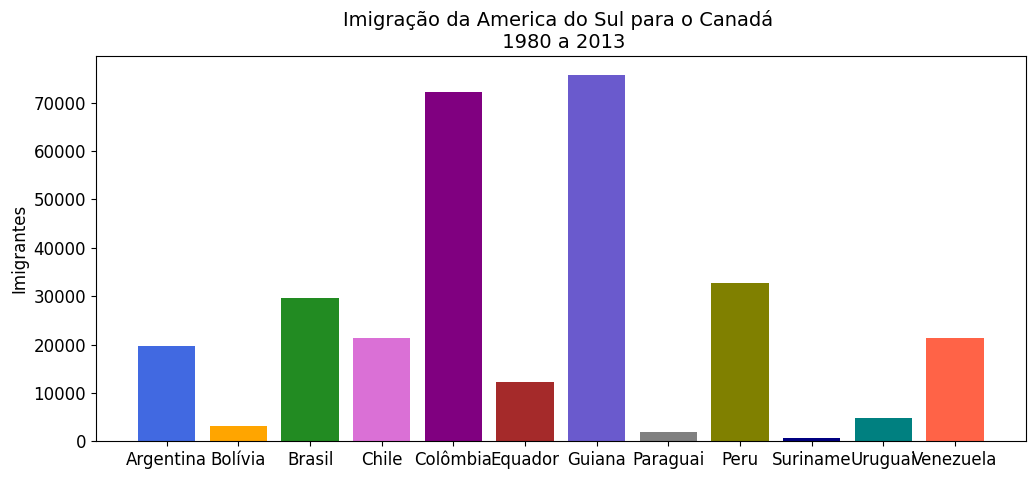

In [27]:
fig, ax = plt.subplots(figsize=(12,5))

ax.bar(america_sul.index, america_sul['Total'], color=cores)
ax.set_title('Imigração da America do Sul para o Canadá \n 1980 a 2013', fontsize=14)
ax.set_xlabel('')
ax.set_ylabel('Imigrantes', fontsize=12)
ax.xaxis.set_tick_params(labelsize=12)
ax.yaxis.set_tick_params(labelsize=12)

plt.show()

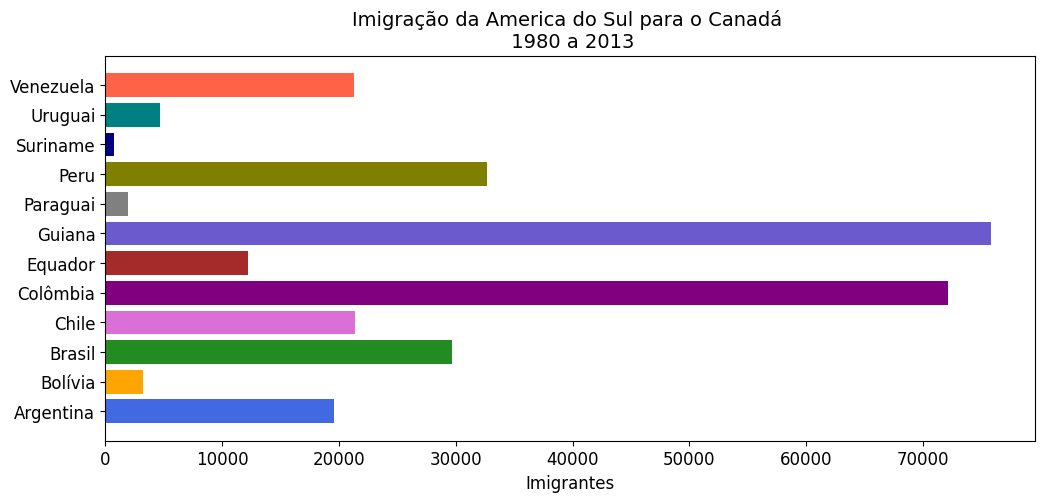

In [28]:
fig, ax = plt.subplots(figsize=(12,5))

ax.barh(america_sul.index, america_sul['Total'], color=cores)
ax.set_title('Imigração da America do Sul para o Canadá \n 1980 a 2013', fontsize=14)
ax.set_xlabel('Imigrantes', fontsize=12)
ax.set_ylabel('')
ax.xaxis.set_tick_params(labelsize=12)
ax.yaxis.set_tick_params(labelsize=12)

plt.show()

In [29]:
america_sul_sorted = america_sul.sort_values('Total', ascending=True)
america_sul_sorted

,Continente,Região,1980,1981,1982,1983,1984,1985,1986,1987,...,2005,2006,2007,2008,2009,2010,2011,2012,2013,Total
País,,,,,,,,,,,,,,,,,,,,,
Suriname,América Latina e o Caribe,América do Sul,15,10,21,12,5,16,7,46,...,15,16,20,9,12,13,11,16,4,739
Paraguai,América Latina e o Caribe,América do Sul,45,26,32,40,48,36,34,72,...,75,88,98,95,88,89,83,55,66,1944
Bolívia,América Latina e o Caribe,América do Sul,44,52,42,49,38,44,79,165,...,134,139,107,143,214,180,86,83,107,3205
Uruguai,América Latina e o Caribe,América do Sul,128,132,146,105,90,92,137,269,...,217,175,147,160,99,93,81,47,58,4715
Equador,América Latina e o Caribe,América do Sul,238,207,184,155,179,208,240,344,...,491,525,419,437,373,353,348,282,418,12233
Argentina,América Latina e o Caribe,América do Sul,368,426,626,241,237,196,213,519,...,1153,847,620,540,467,459,278,263,282,19596
Venezuela,América Latina e o Caribe,América do Sul,103,117,174,124,142,165,179,229,...,1211,1192,1335,1239,1353,998,1452,1373,1022,21267
Chile,América Latina e o Caribe,América do Sul,1233,1069,1078,781,681,533,633,1454,...,384,427,530,350,375,340,174,291,273,21359
Brasil,América Latina e o Caribe,América do Sul,211,220,192,139,145,130,205,244,...,969,1181,1746,2138,2509,2598,1508,1642,1714,29659


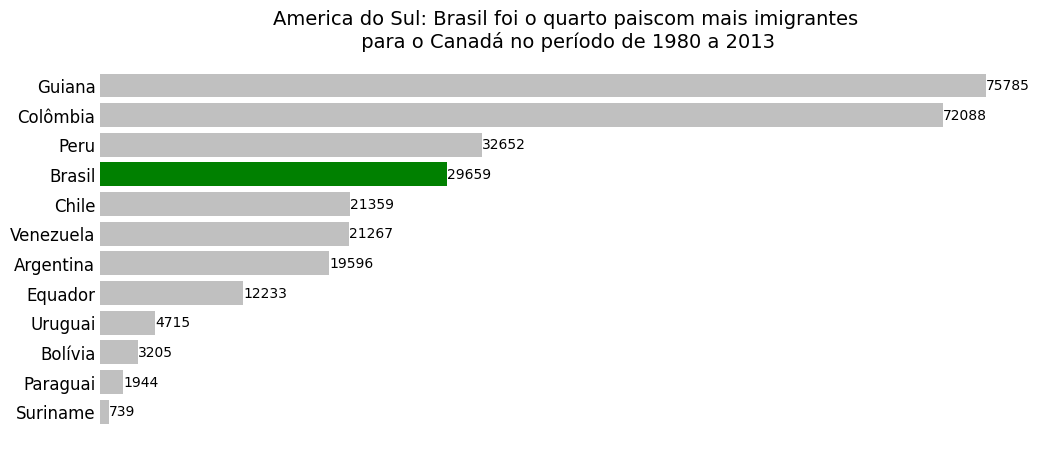

In [34]:
cores = []

for pais in america_sul_sorted.index:
  if pais == 'Brasil':
    cores.append('green')
  else:
    cores.append('silver')

fig, ax = plt.subplots(figsize=(12,5))

ax.barh(america_sul_sorted.index, america_sul_sorted['Total'], color=cores)
ax.set_title('America do Sul: Brasil foi o quarto paiscom mais imigrantes\n para o Canadá no período de 1980 a 2013', fontsize=14)
ax.set_xlabel('Imigrantes')
ax.set_ylabel('', fontsize=12)
ax.xaxis.set_tick_params(labelsize=12)
ax.yaxis.set_tick_params(labelsize=12)

for i, v in enumerate(america_sul_sorted['Total']):
  ax.text(v + 20, i, str(v), color='black', fontsize=10, ha='left', va='center')

ax.set_frame_on(False)
ax.get_xaxis().set_visible(False)
ax.tick_params(axis='both', which='both', length=0)

fig.savefig('imigracao_america_sul.png', transparent=False, dpi=300, bbox_inches='tight')

plt.show()

In [31]:
print(fig.canvas.get_supported_filetypes())

{'eps': 'Encapsulated Postscript', 'jpg': 'Joint Photographic Experts Group', 'jpeg': 'Joint Photographic Experts Group', 'pdf': 'Portable Document Format', 'pgf': 'PGF code for LaTeX', 'png': 'Portable Network Graphics', 'ps': 'Postscript', 'raw': 'Raw RGBA bitmap', 'rgba': 'Raw RGBA bitmap', 'svg': 'Scalable Vector Graphics', 'svgz': 'Scalable Vector Graphics', 'tif': 'Tagged Image File Format', 'tiff': 'Tagged Image File Format', 'webp': 'WebP Image Format'}


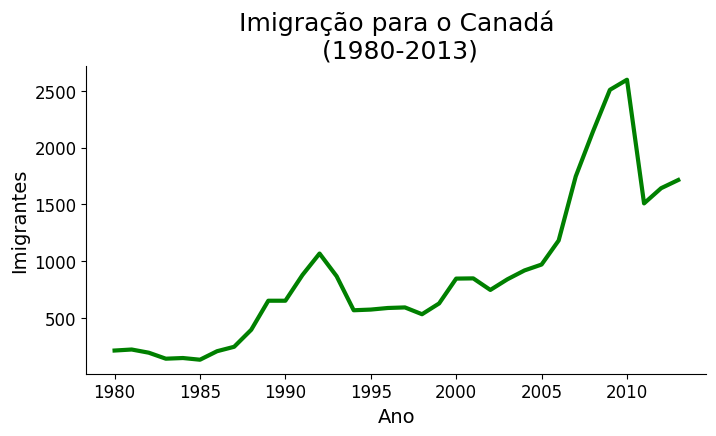

In [33]:
fig, ax = plt.subplots(figsize=(8,4))
ax.plot(dados_brasil['ano'], dados_brasil['imigrantes'], lw=3, color='green')
ax.set_title('Imigração para o Canadá\n (1980-2013)', fontsize=18)
ax.set_xlabel('Ano', fontsize=14)
ax.set_ylabel('Imigrantes', fontsize=14)
ax.xaxis.set_tick_params(labelsize=12)
ax.yaxis.set_tick_params(labelsize=12)
ax.xaxis.set_major_locator(plt.MultipleLocator(5))
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

fig.savefig('imigracao_brasil_canada.png', transparent=False, dpi=300, bbox_inches='tight')
plt.show()

In [35]:
import seaborn as sns

In [36]:
sns.set_theme()

In [37]:
top_10 = df.sort_values('Total', ascending=False).head(10)
top_10

,Continente,Região,1980,1981,1982,1983,1984,1985,1986,1987,...,2005,2006,2007,2008,2009,2010,2011,2012,2013,Total
País,,,,,,,,,,,,,,,,,,,,,
Índia,Ásia,Sul da Ásia,8880,8670,8147,7338,5704,4211,7150,10189,...,36210,33848,28742,28261,29456,34235,27509,30933,33087,691904
China,Ásia,Ásia Oriental,5123,6682,3308,1863,1527,1816,1960,2643,...,42584,33518,27642,30037,29622,30391,28502,33024,34129,659962
Reino Unido e Irlanda do Norte,Europa,Norte da Europa,22045,24796,20620,10015,10170,9564,9470,21337,...,7258,7140,8216,8979,8876,8724,6204,6195,5827,551500
Filipinas,Ásia,Sudeste Asiático,6051,5921,5249,4562,3801,3150,4166,7360,...,18139,18400,19837,24887,28573,38617,36765,34315,29544,511391
Paquistão,Ásia,Sul da Ásia,978,972,1201,900,668,514,691,1072,...,14314,13127,10124,8994,7217,6811,7468,11227,12603,241600
Estados Unidos da América,América do Norte,América do Norte,9378,10030,9074,7100,6661,6543,7074,7705,...,8394,9613,9463,10190,8995,8142,7676,7891,8501,241122
Irã,Ásia,Sul da Ásia,1172,1429,1822,1592,1977,1648,1794,2989,...,5837,7480,6974,6475,6580,7477,7479,7534,11291,175923
Sri Lanka,Ásia,Sul da Ásia,185,371,290,197,1086,845,1838,4447,...,4930,4714,4123,4756,4547,4422,3309,3338,2394,148358
República da Coreia,Ásia,Ásia Oriental,1011,1456,1572,1081,847,962,1208,2338,...,5832,6215,5920,7294,5874,5537,4588,5316,4509,142581


<Axes: xlabel='País', ylabel='Total'>

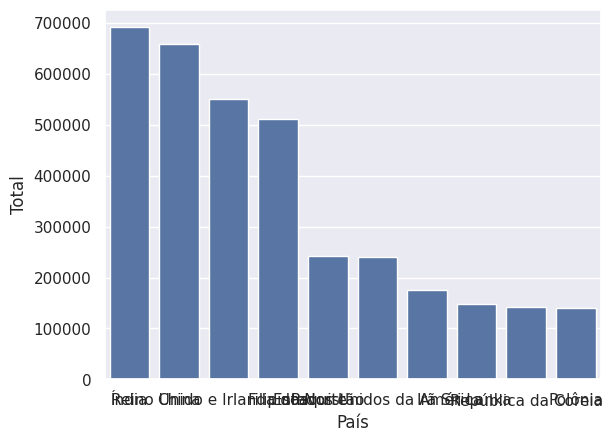

In [38]:
sns.barplot(data=top_10, x = top_10.index, y = 'Total')

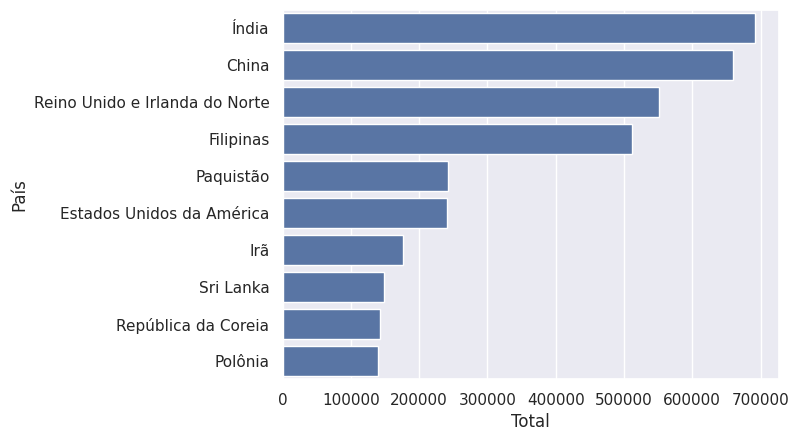

In [41]:
sns.barplot(data=top_10, x = 'Total', y = top_10.index, orient='h')
plt.show()

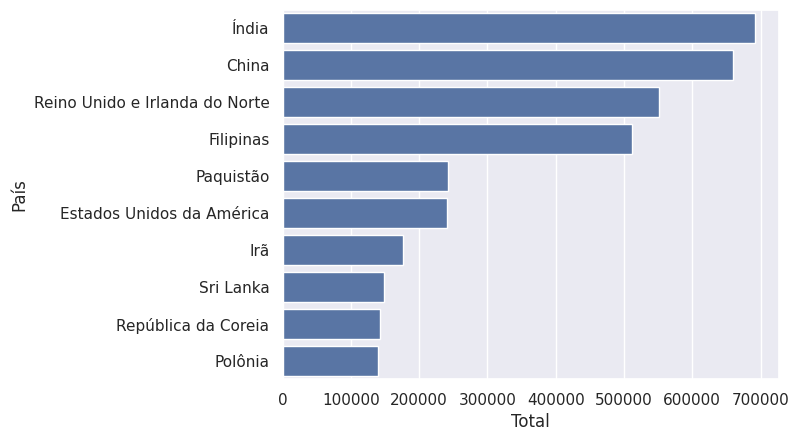

In [44]:
sns.barplot(data=top_10, x = 'Total', y = top_10.index, orient='h')

ax.set(title='Países com maior imigração para o Canadá',
       xlabel='Números de Imigrantes',
       ylabel='')
plt.show()

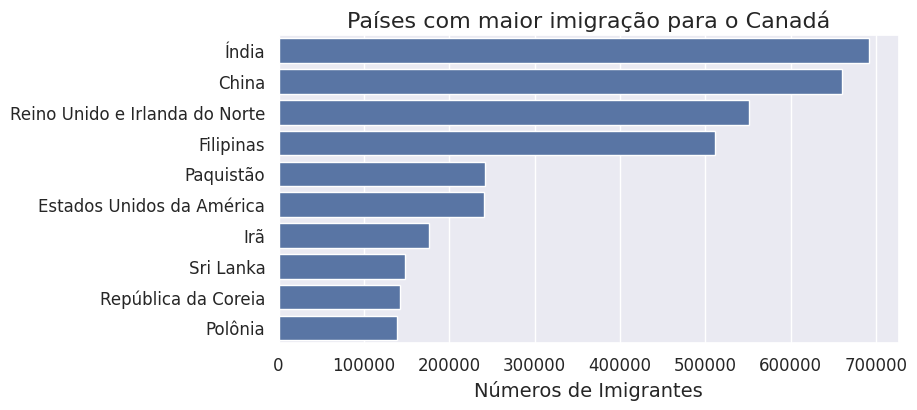

In [47]:
fig, ax = plt.subplots(figsize=(8,4))
ax = sns.barplot(data=top_10, x = 'Total', y = top_10.index, orient='h')

ax.set_title('Países com maior imigração para o Canadá', fontsize=16)
ax.set_xlabel('Números de Imigrantes', fontsize=14)
ax.set_ylabel('')
ax.xaxis.set_tick_params(labelsize=12)
ax.yaxis.set_tick_params(labelsize=12)
plt.show()

In [50]:
def GerarGrafico(pallete):
  fig, ax = plt.subplots(figsize=(8,4))
  ax = sns.barplot(data=top_10, x = 'Total', y = top_10.index, orient='h', palette=pallete, hue='Total')
  ax.set_title('Países com maior imigração para o Canadá', fontsize=16)
  ax.set_xlabel('Números de Imigrantes', fontsize=14)
  ax.set_ylabel('')
  ax.xaxis.set_tick_params(labelsize=12)
  ax.yaxis.set_tick_params(labelsize=12)

  plt.show()

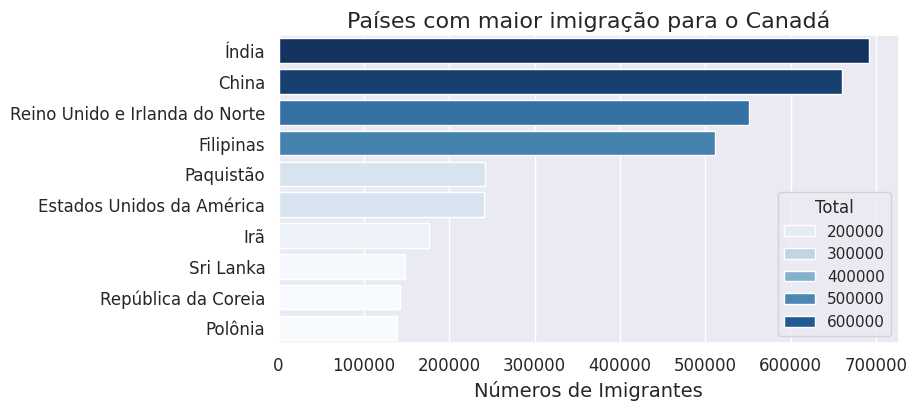

In [51]:
GerarGrafico('Blues')

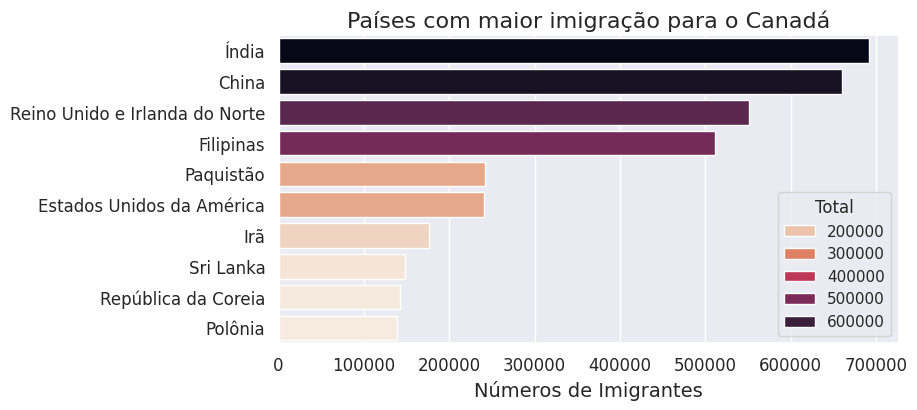

In [53]:
GerarGrafico('rocket_r')

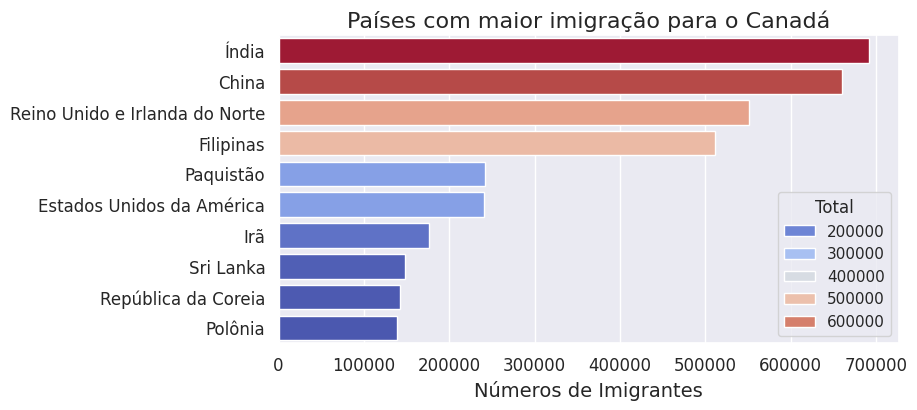

In [54]:
GerarGrafico('coolwarm')

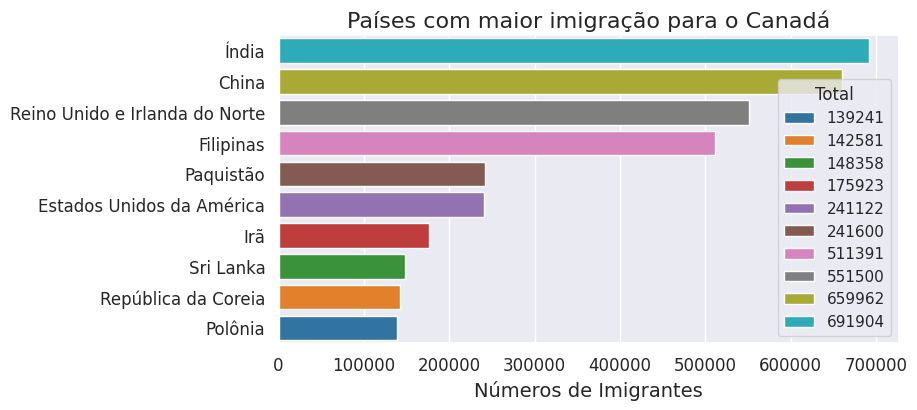

In [55]:
GerarGrafico('tab10')

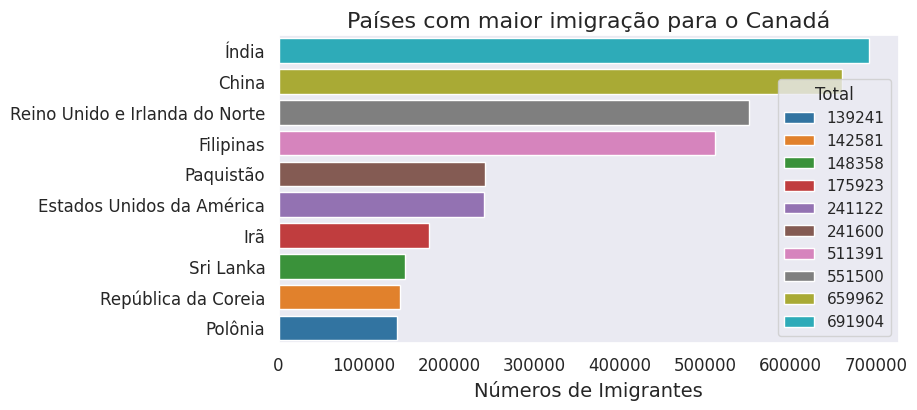

In [56]:
sns.set_theme(style='dark')
GerarGrafico('tab10')

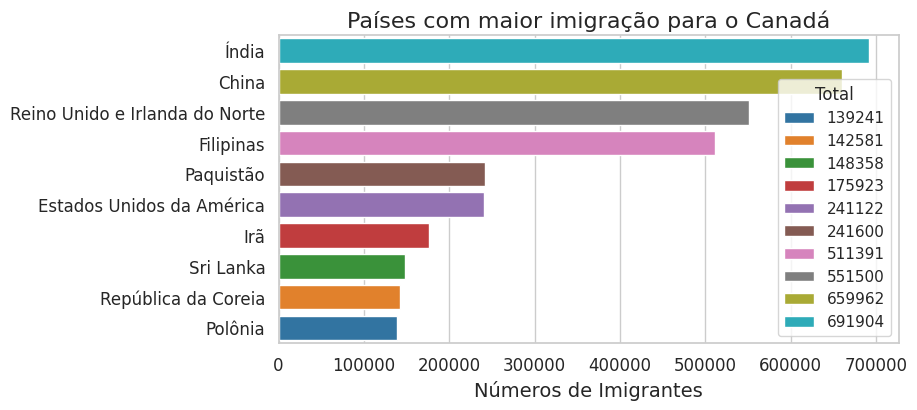

In [57]:
sns.set_theme(style='whitegrid')
GerarGrafico('tab10')

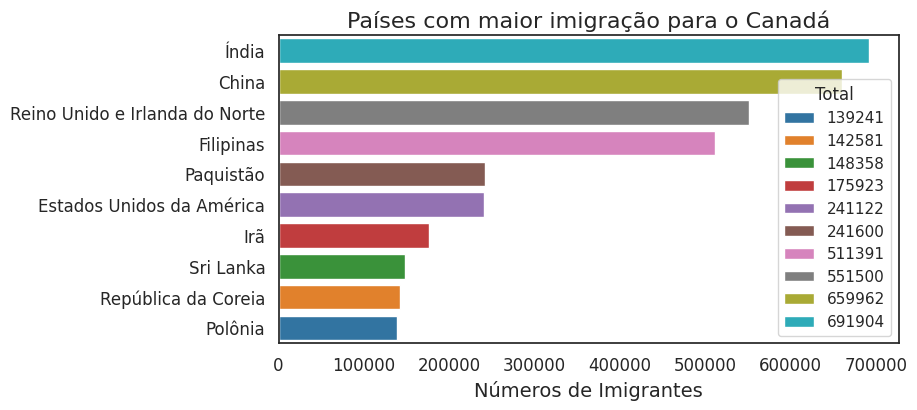

In [58]:
sns.set_theme(style='white')
GerarGrafico('tab10')

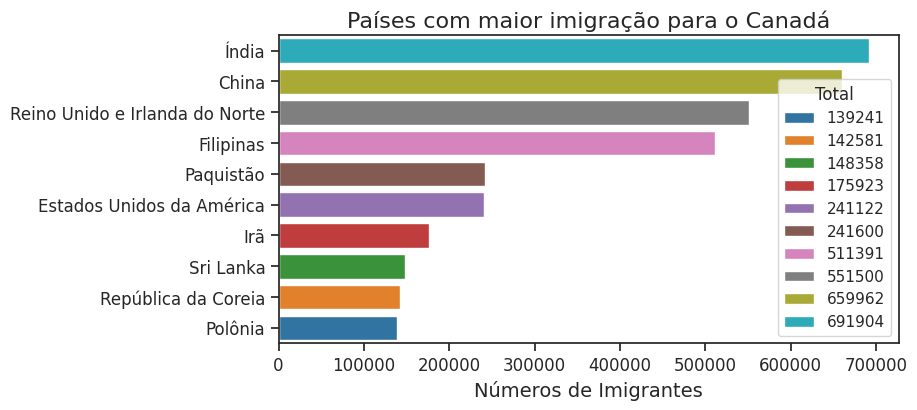

In [59]:
sns.set_theme(style='ticks')
GerarGrafico('tab10')

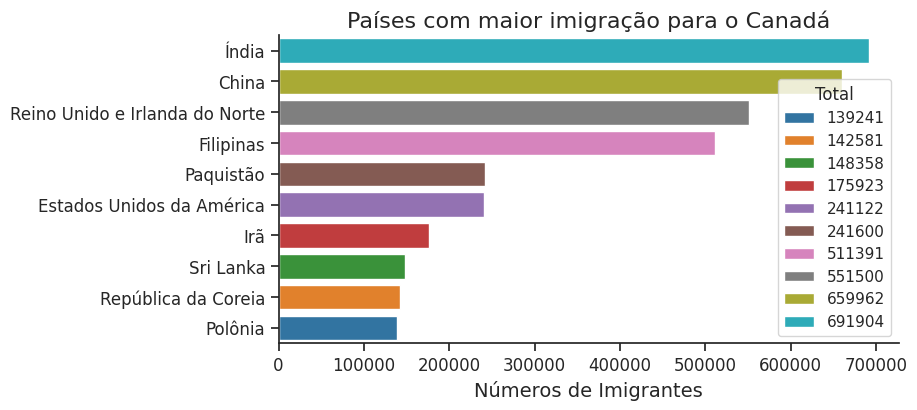

In [60]:
fig, ax = plt.subplots(figsize=(8,4))
ax = sns.barplot(data=top_10, x = 'Total', y = top_10.index, orient='h', palette='tab10', hue='Total')

ax.set_title('Países com maior imigração para o Canadá', fontsize=16)
ax.set_xlabel('Números de Imigrantes', fontsize=14)
ax.set_ylabel('')
ax.xaxis.set_tick_params(labelsize=12)
ax.yaxis.set_tick_params(labelsize=12)
sns.despine()

plt.show()

In [61]:
import plotly.express as px

In [73]:
fig = px.line(dados_brasil, x='ano', y='imigrantes',
              title='Imigração para o Canadá (1980-2013)')

fig.update_traces(line_color='green', line_width=4)

fig.update_layout(width=1000, height=500,
                  xaxis={'tickangle':-45},
                  xaxis_title='Ano',
                  yaxis_title='Número de Imigrantes',
                  font_family='Arial',
                  font_size=14,
                  font_color='grey',
                  title_font_color='black',
                  title_font_size=22)
fig.show()

In [75]:
america_sul.head()

,Continente,Região,1980,1981,1982,1983,1984,1985,1986,1987,...,2005,2006,2007,2008,2009,2010,2011,2012,2013,Total
País,,,,,,,,,,,,,,,,,,,,,
Argentina,América Latina e o Caribe,América do Sul,368,426,626,241,237,196,213,519,...,1153,847,620,540,467,459,278,263,282,19596
Bolívia,América Latina e o Caribe,América do Sul,44,52,42,49,38,44,79,165,...,134,139,107,143,214,180,86,83,107,3205
Brasil,América Latina e o Caribe,América do Sul,211,220,192,139,145,130,205,244,...,969,1181,1746,2138,2509,2598,1508,1642,1714,29659
Chile,América Latina e o Caribe,América do Sul,1233,1069,1078,781,681,533,633,1454,...,384,427,530,350,375,340,174,291,273,21359
Colômbia,América Latina e o Caribe,América do Sul,266,326,360,244,235,214,257,376,...,6424,6535,5357,5452,4652,5218,4366,3741,3631,72088


In [77]:
df_america_sul_clean = america_sul.drop(['Total', 'Região', 'Continente'], axis=1)
america_sul_final = df_america_sul_clean.T
america_sul_final

País,Argentina,Bolívia,Brasil,Chile,Colômbia,Equador,Guiana,Paraguai,Peru,Suriname,Uruguai,Venezuela
1980,368,44,211,1233,266,238,2334,45,317,15,128,103
1981,426,52,220,1069,326,207,2943,26,456,10,132,117
1982,626,42,192,1078,360,184,3575,32,401,21,146,174
1983,241,49,139,781,244,155,2650,40,241,12,105,124
1984,237,38,145,681,235,179,1932,48,306,5,90,142
1985,196,44,130,533,214,208,2299,36,328,16,92,165
1986,213,79,205,633,257,240,3942,34,628,7,137,179
1987,519,165,244,1454,376,344,6174,72,843,46,269,229
1988,374,63,394,990,352,265,2977,53,1237,16,99,279
1989,538,68,650,1023,439,278,3270,48,1667,24,144,304


In [81]:
fig = px.line(america_sul_final, x=america_sul_final.index, y=america_sul_final.columns, color='País',
              title='Imigração dos paises da America do Sul para o Canadá (1980-2013)', markers=True)

fig.update_layout(
    xaxis={'tickangle':-45},
    xaxis_title='Ano',
    yaxis_title='Número de Imigrantes')

fig.show()

In [82]:
fig.write_html('imigracao_america_sul.html')

In [83]:
dados_brasil['ano'] = dados_brasil['ano'].astype(int)

In [84]:
import plotly.graph_objs as go

In [86]:
fig = go.Figure()
fig.add_trace(
    go.Scatter(x=[dados_brasil['ano'].iloc[0]], y=[dados_brasil['imigrantes'].iloc[0]], mode='lines', name='Imigrantes', line=dict(width=4))
)

fig.update_layout(
    title=dict(
        text='<b>Imigração do Brasil para o Canadá no período de 1980 a 2013</b>',
        x=0.12,
        xanchor='left',
        font=dict(size=20)
    ),
    xaxis=dict(range=[1980, 2013], autorange=False, title='<b>Ano</b>'),
    yaxis=dict(range=[0, 3000], autorange=False, title='<b>Número de imigrantes</b>'),
    updatemenus=[dict(
        type='buttons',
        showactive=False,
        buttons=[dict(
            label='Play',
            method='animate',
            args=[None, {'frame': {'duration': 100, 'redraw': True}, 'fromcurrent': True}]
        )]
    )],
    width=1000,
    height=500
)

frames = [go.Frame(data=[go.Scatter(x=dados_brasil['ano'].iloc[:i+1], y=dados_brasil['imigrantes'].iloc[:i+1])]) for i in range(len(dados_brasil))]
fig.frames = frames

fig.show()

In [87]:
fig.write_html('imigracao_america_sul_animacao.html')